<a href="https://colab.research.google.com/github/roalddalhwriter/isro/blob/main/Hyperspectral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install spectral -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 9.6 MB/s eta 0:00:00


In [ ]:
import spectral.io.envi as envi
import numpy as np

BASE = '/content/drive/MyDrive/Aviris'
img = envi.open(
    BASE + '/quack 3357 final spactial subset.hdr',
    BASE + '/quack 3357 final spactial subset'
)

print(f"Shape: {img.nrows} x {img.ncols} x {img.nbands}")
print(f"Wavelengths: {img.bands.centers[0]:.1f} -> {img.bands.centers[-1]:.1f} nm")
print(f"Est. RAM if fully loaded: {img.nrows * img.ncols * img.nbands * 4 / 1e9:.2f} GB")

Shape: 3047 x 578 x 322
Wavelengths: 432.2 -> 2465.7 nm
Est. RAM if fully loaded: 2.27 GB


In [ ]:
# Cell 3 — Bad band removal (mask water vapor regions)
import numpy as np

wavelengths = np.array(img.bands.centers)

# Water vapor absorption bands — hardcoded, standard for AVIRIS-NG
bad_mask = (
    ((wavelengths >= 1340) & (wavelengths <= 1445)) |
    ((wavelengths >= 1790) & (wavelengths <= 1955))
)
good_bands = np.where(~bad_mask)[0]
print(f"Good bands: {len(good_bands)} / {img.nbands}")

Good bands: 321 / 322


In [ ]:
# Cell 4 — Memory efficient loading (process in chunks, don't store full cube)
from sklearn.decomposition import IncrementalPCA

nrows, ncols = img.nrows, img.ncols
nbands = len(good_bands)
chunk_size = 100  # smaller chunks

# Step 1: Fit IncrementalPCA without storing full data
ipca = IncrementalPCA(n_components=20)

for start in range(0, nrows, chunk_size):
    end = min(start + chunk_size, nrows)
    chunk = img.read_subregion((start, end), (0, ncols))
    chunk = chunk[:, :, good_bands].astype(np.float32)
    chunk = chunk.reshape(-1, nbands)

    # normalize
    mean = chunk.mean(axis=1, keepdims=True)
    mean[mean == 0] = 1
    chunk = chunk / mean

    # remove dead pixels
    valid = chunk.mean(axis=1) > 0
    if valid.sum() > 20:
        ipca.partial_fit(chunk[valid])

    print(f"PCA fit rows {start}-{end}")

print(f"Variance explained: {ipca.explained_variance_ratio_.sum()*100:.1f}%")

PCA fit rows 0-100
PCA fit rows 100-200
PCA fit rows 200-300
PCA fit rows 300-400
PCA fit rows 400-500
PCA fit rows 500-600
PCA fit rows 600-700
PCA fit rows 700-800
PCA fit rows 800-900
PCA fit rows 900-1000
PCA fit rows 1000-1100
PCA fit rows 1100-1200
PCA fit rows 1200-1300
PCA fit rows 1300-1400
PCA fit rows 1400-1500
PCA fit rows 1500-1600
PCA fit rows 1600-1700
PCA fit rows 1700-1800
PCA fit rows 1800-1900
PCA fit rows 1900-2000
PCA fit rows 2000-2100
PCA fit rows 2100-2200
PCA fit rows 2200-2300
PCA fit rows 2300-2400
PCA fit rows 2400-2500
PCA fit rows 2500-2600
PCA fit rows 2600-2700
PCA fit rows 2700-2800
PCA fit rows 2800-2900
PCA fit rows 2900-3000
PCA fit rows 3000-3047
Variance explained: 100.0%


In [ ]:
# Cell 5 — Transform in chunks + collect PCA output
pca_result = []
valid_mask = []

for start in range(0, nrows, chunk_size):
    end = min(start + chunk_size, nrows)
    chunk = img.read_subregion((start, end), (0, ncols))
    chunk = chunk[:, :, good_bands].astype(np.float32)
    chunk = chunk.reshape(-1, nbands)

    mean = chunk.mean(axis=1, keepdims=True)
    mean[mean == 0] = 1
    chunk = chunk / mean

    valid = chunk.mean(axis=1) > 0
    transformed = ipca.transform(chunk[valid])

    pca_result.append(transformed)
    valid_mask.append(valid)
    print(f"Transformed rows {start}-{end}")

pca_result = np.vstack(pca_result)
valid_mask = np.concatenate(valid_mask)
print(f"PCA shape: {pca_result.shape}")

Transformed rows 0-100
Transformed rows 100-200
Transformed rows 200-300
Transformed rows 300-400
Transformed rows 400-500
Transformed rows 500-600
Transformed rows 600-700
Transformed rows 700-800
Transformed rows 800-900
Transformed rows 900-1000
Transformed rows 1000-1100
Transformed rows 1100-1200
Transformed rows 1200-1300
Transformed rows 1300-1400
Transformed rows 1400-1500
Transformed rows 1500-1600
Transformed rows 1600-1700
Transformed rows 1700-1800
Transformed rows 1800-1900
Transformed rows 1900-2000
Transformed rows 2000-2100
Transformed rows 2100-2200
Transformed rows 2200-2300
Transformed rows 2300-2400
Transformed rows 2400-2500
Transformed rows 2500-2600
Transformed rows 2600-2700
Transformed rows 2700-2800
Transformed rows 2800-2900
Transformed rows 2900-3000
Transformed rows 3000-3047
PCA shape: (1761166, 20)


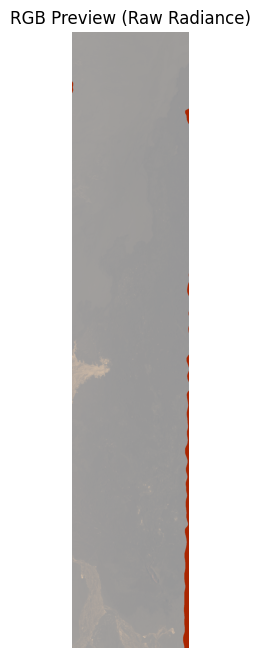

In [ ]:
# Cell 6 — RGB preview (check scene looks correct)
import matplotlib.pyplot as plt

wavelengths_good = wavelengths[good_bands]

r_idx = np.argmin(np.abs(wavelengths_good - 650))
g_idx = np.argmin(np.abs(wavelengths_good - 550))
b_idx = np.argmin(np.abs(wavelengths_good - 450))

rgb = data[:, :, [r_idx, g_idx, b_idx]]
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())  # normalize to 0-1

plt.figure(figsize=(12, 8))
plt.imshow(rgb)
plt.title("RGB Preview (Raw Radiance)")
plt.axis('off')
plt.show()

In [ ]:
# Cell 8 — K-Means clustering
from sklearn.cluster import MiniBatchKMeans

K = 4  # try 6-10, change this freely

kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=10000)
labels_valid = kmeans.fit_predict(pca_result)

# Map back to full image
labels_full = np.full(nrows * ncols, -1, dtype=np.int16)
labels_full[valid_mask] = labels_valid
cluster_map = labels_full.reshape(nrows, ncols)

print("Clustering done.")

Clustering done.


/tmp/ipykernel_882/1679403536.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', K)


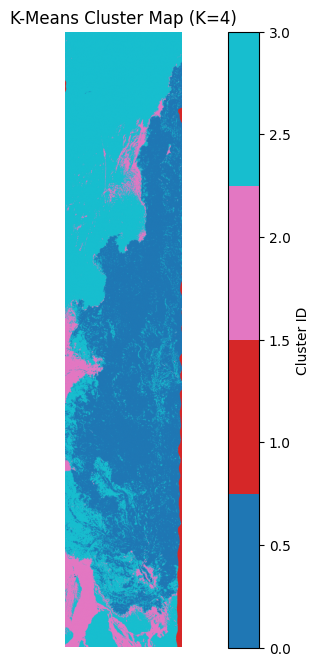

In [ ]:
# Cell 9 — Visualize cluster map
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cmap = plt.cm.get_cmap('tab10', K)

plt.figure(figsize=(12, 8))
plt.imshow(cluster_map, cmap=cmap, vmin=0, vmax=K-1)
plt.colorbar(label='Cluster ID')
plt.title(f"K-Means Cluster Map (K={K})")
plt.axis('off')
plt.show()

In [ ]:
for k in range(K):
    count = (cluster_map.flatten() == k).sum()
    print(f"Cluster {k}: {count} pixels ({count/(img.nrows*img.ncols)*100:.1f}%)")

Cluster 0: 819551 pixels (46.5%)
Cluster 1: 22330 pixels (1.3%)
Cluster 2: 147477 pixels (8.4%)
Cluster 3: 771808 pixels (43.8%)


/tmp/ipykernel_882/1916836046.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  axes[1].imshow(cluster_map, cmap=plt.cm.get_cmap('tab10', K), vmin=0, vmax=K-1)


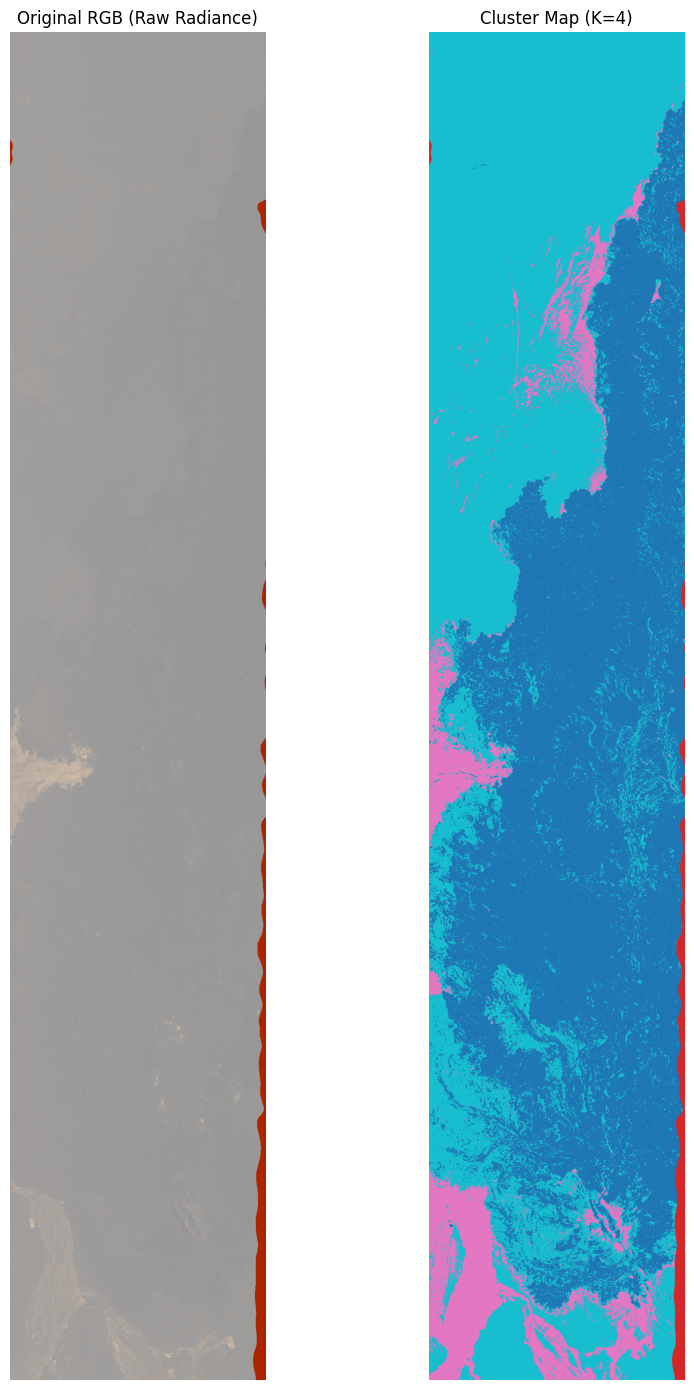

In [ ]:
# Reload raw for RGB
raw_check = img.read_subregion((0, img.nrows), (0, img.ncols))

r_idx = np.argmin(np.abs(wavelengths - 650))
g_idx = np.argmin(np.abs(wavelengths - 550))
b_idx = np.argmin(np.abs(wavelengths - 450))

rgb_raw = raw_check[:, :, [r_idx, g_idx, b_idx]].astype(np.float32)
rgb_raw = (rgb_raw - rgb_raw.min()) / (rgb_raw.max() - rgb_raw.min())

fig, axes = plt.subplots(1, 2, figsize=(10, 14))
axes[0].imshow(rgb_raw)
axes[0].set_title("Original RGB (Raw Radiance)")
axes[0].axis('off')

axes[1].imshow(cluster_map, cmap=plt.cm.get_cmap('tab10', K), vmin=0, vmax=K-1)
axes[1].set_title(f"Cluster Map (K={K})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Random Forest on K-Means pseudo-labels
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

# Get labels for valid pixels only
km_labels = cluster_map.flatten()[valid_mask]

# Remove noisy cluster 1
clean_mask = km_labels != 1
X = pca_result[clean_mask]
y = km_labels[clean_mask]

# Subsample for speed — 200k pixels is enough
np.random.seed(42)
sample_idx = np.random.choice(len(X), min(200000, len(X)), replace=False)
X_sample = X[sample_idx]
y_sample = y[sample_idx]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

print(f"Training on {len(X_train)} pixels, testing on {len(X_test)}")

Training on 160000 pixels, testing on 40000


In [ ]:
# Train
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   34.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.2min finished


RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42, verbose=1)

In [ ]:
# Evaluate
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18865
           2       1.00      1.00      1.00      3431
           3       1.00      1.00      1.00     17704

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.4s finished


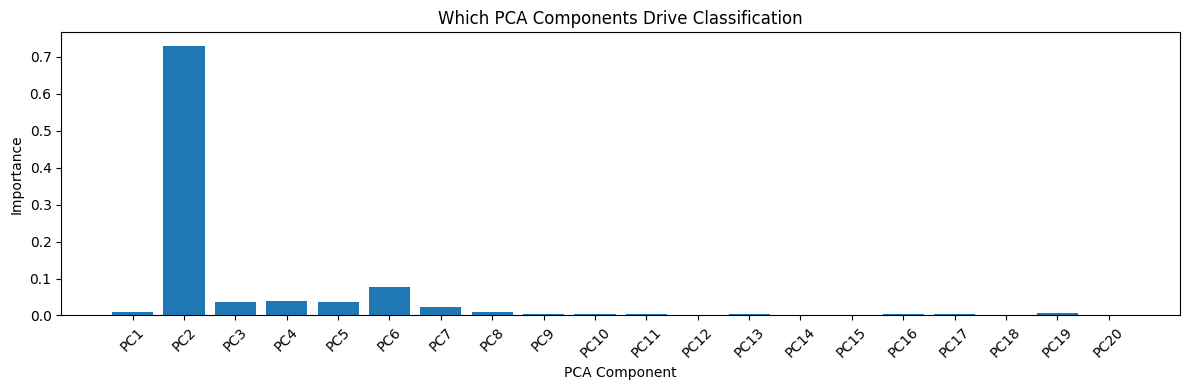

In [ ]:
# Feature importance — which PCA components matter most
import matplotlib.pyplot as plt

importances = rf.feature_importances_
plt.figure(figsize=(12, 4))
plt.bar(range(20), importances)
plt.xlabel('PCA Component')
plt.ylabel('Importance')
plt.title('Which PCA Components Drive Classification')
plt.xticks(range(20), [f'PC{i+1}' for i in range(20)], rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Predict full image + confidence map
rf_labels = np.full(len(valid_mask), -1, dtype=np.int16)
rf_proba = np.zeros(len(valid_mask), dtype=np.float32)

# Predict in batches to avoid OOM
batch = 100000
valid_indices = np.where(valid_mask)[0]
clean_valid = km_labels != 1  # same clean mask

for start in range(0, len(valid_indices), batch):
    end = min(start + batch, len(valid_indices))
    idx = valid_indices[start:end]
    pca_batch = pca_result[start:end]
    rf_labels[idx] = rf.predict(pca_batch)
    rf_proba[idx] = rf.predict_proba(pca_batch).max(axis=1)
    print(f"Predicted {end}/{len(valid_indices)}")

rf_map = rf_labels.reshape(nrows, ncols)
conf_map = rf_proba.reshape(nrows, ncols)

NameError: name 'np' is not defined

In [ ]:
wavelengths_good = wavelengths[good_bands]
r_idx = np.argmin(np.abs(wavelengths_good - 650))
g_idx = np.argmin(np.abs(wavelengths_good - 550))
b_idx = np.argmin(np.abs(wavelengths_good - 450))

chunk = img.read_subregion((0, img.nrows), (0, img.ncols))
rgb = chunk[:, :, good_bands][:, :, [r_idx, g_idx, b_idx]].astype(np.float32)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

NameError: name 'wavelengths' is not defined

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 14))

axes[0].imshow(rgb)
axes[0].set_title("RGB")
axes[0].axis('off')

axes[1].imshow(rf_map, cmap=plt.cm.get_cmap('tab10', K), vmin=0, vmax=K-1)
axes[1].set_title("Random Forest Map")
axes[1].axis('off')

axes[2].imshow(conf_map, cmap='RdYlGn', vmin=0, vmax=1)
axes[2].set_title("Confidence Map")
axes[2].axis('off')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

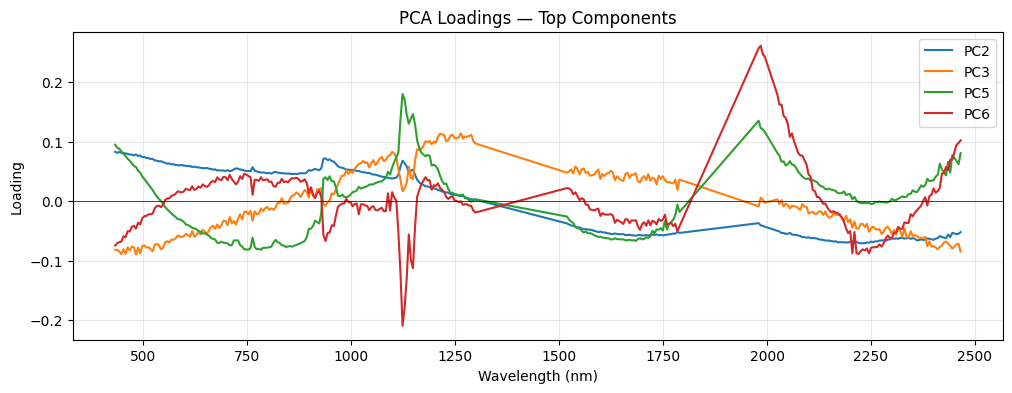

In [ ]:
# What does PC2 look like in wavelength space
wavelengths_good = wavelengths[good_bands]

plt.figure(figsize=(12, 4))
for i, pc in enumerate([1, 2, 4, 5]):  # PC2, PC3, PC5, PC6 (0-indexed)
    plt.plot(wavelengths_good, ipca.components_[pc], label=f'PC{pc+1}')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Loading')
plt.title('PCA Loadings — Top Components')
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
!pip install spectral -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 5.9 MB/s eta 0:00:00


In [ ]:
plt.close('all')

Good bands: 358
Fitting KMeans...
  Fit rows 0/1029
  Fit rows 500/1029
  Fit rows 1000/1029
Fitting done. Predicting...
  Predicted rows 0/1029
  Predicted rows 500/1029
  Predicted rows 1000/1029
Prediction done.
Loading only RGB bands to save RAM...
Generating Plots...


/tmp/ipykernel_7825/1833529307.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  current_cmap = plt.cm.get_cmap('tab10', K)


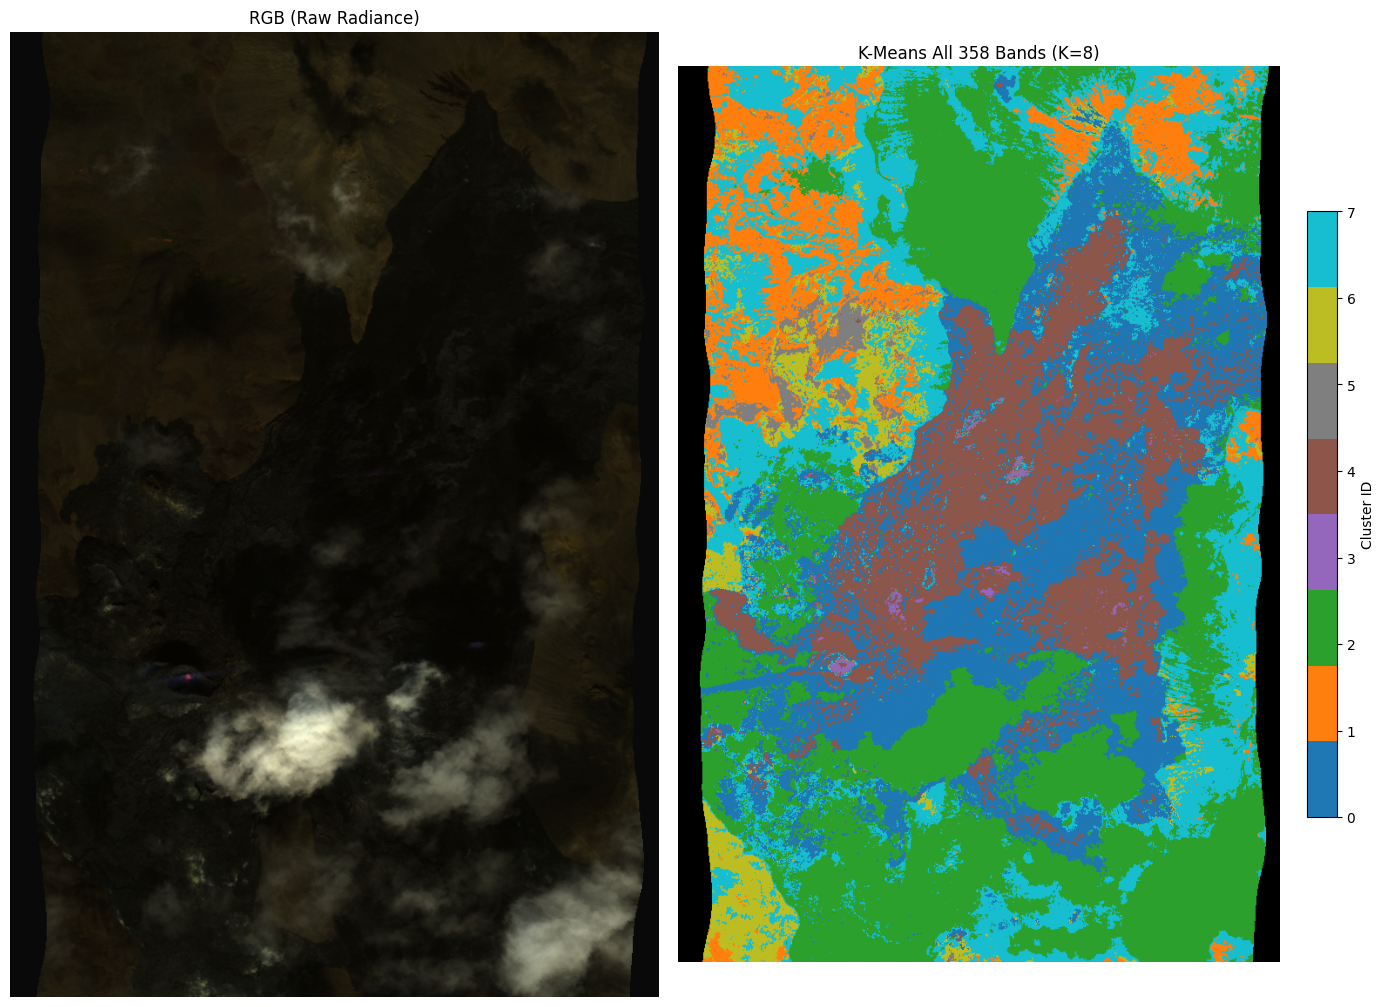

Plots generated successfully and saved as 'kmeans_raw_output.png'!

Cluster pixel counts:
  Cluster 0: 136991 pixels (19.3%)
  Cluster 1: 54068 pixels (7.6%)
  Cluster 2: 198378 pixels (27.9%)
  Cluster 3: 1647 pixels (0.2%)
  Cluster 4: 99837 pixels (14.0%)
  Cluster 5: 9633 pixels (1.4%)
  Cluster 6: 30130 pixels (4.2%)
  Cluster 7: 123934 pixels (17.4%)


In [ ]:
# ============================================================
# FULL PIPELINE — One Cell
# Hyperspectral K-Means on all 321 bands (no PCA)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import spectral.io.envi as envi

# ---- Config ----
BASE = '/content/drive/MyDrive/Aviris'
HDR  = BASE + '/142 out reflec.hdr'
IMG  = BASE + '/142 out reflec'
K    = 8

# ---- Load cube ----
img = envi.open(HDR, IMG)
nrows, ncols = img.nrows, img.ncols
wavelengths = np.array(img.bands.centers)

# ---- Bad band removal ----
bad_mask = (
    ((wavelengths >= 1340) & (wavelengths <= 1445)) |
    ((wavelengths >= 1790) & (wavelengths <= 1955))
)
good_bands = np.where(~bad_mask)[0]
nbands = len(good_bands)
print(f"Good bands: {nbands}")

# ---- Fit MiniBatchKMeans in chunks ----
kmeans_raw = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=5000, n_init=3)
CHUNK = 100

print("Fitting KMeans...")
for start in range(0, nrows, CHUNK):
    end = min(start + CHUNK, nrows)
    chunk = img.read_subregion((start, end), (0, ncols))
    chunk = chunk[:, :, good_bands].astype(np.float32).reshape(-1, nbands)
    mean = chunk.mean(axis=1, keepdims=True)
    mean[mean == 0] = 1
    chunk = chunk / mean
    valid = chunk.mean(axis=1) > 0
    if valid.sum() > 0:
        kmeans_raw.partial_fit(chunk[valid])
    if start % 500 == 0:
        print(f"  Fit rows {start}/{nrows}")

print("Fitting done. Predicting...")

# ---- Predict full image ----
labels_raw = np.full(nrows * ncols, -1, dtype=np.int16)

for start in range(0, nrows, CHUNK):
    end = min(start + CHUNK, nrows)
    chunk = img.read_subregion((start, end), (0, ncols))
    chunk = chunk[:, :, good_bands].astype(np.float32).reshape(-1, nbands)
    mean = chunk.mean(axis=1, keepdims=True)
    mean[mean == 0] = 1
    chunk = chunk / mean
    valid = chunk.mean(axis=1) > 0
    idx = np.arange(start * ncols, end * ncols)
    labels_raw[idx[valid]] = kmeans_raw.predict(chunk[valid])
    if start % 500 == 0:
        print(f"  Predicted rows {start}/{nrows}")

cluster_map_raw = labels_raw.reshape(nrows, ncols)
print("Prediction done.")

# ---- RGB for comparison (RAM Friendly Version) ----
wavelengths_good = wavelengths[good_bands]

# Pehle original bands se indices nikaalo (good_bands ke index nahi, original image ke)
r_idx_orig = np.argmin(np.abs(wavelengths - 650))
g_idx_orig = np.argmin(np.abs(wavelengths - 550))
b_idx_orig = np.argmin(np.abs(wavelengths - 450))

print("Loading only RGB bands to save RAM...")
# Pure data cube ke badle, sirf yeh 3 bands read karo pure rows/cols ke liye
rgb_bands = img.read_subregion((0, nrows), (0, ncols), bands=[r_idx_orig, g_idx_orig, b_idx_orig])
rgb = rgb_bands.astype(np.float32)

# Global normalization (for beautiful contrast)
rgb_min = rgb.min()
rgb_max = rgb.max()
if rgb_max > rgb_min:
    rgb = (rgb - rgb_min) / (rgb_max - rgb_min)
else:
    rgb = np.zeros_like(rgb)

# ---- Plot (Safe & Explicit) ----
print("Generating Plots...")
plt.figure(figsize=(14, 10))

# Subplot 1: RGB
plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("RGB (Raw Radiance)")
plt.axis('off')

# Subplot 2: Cluster Map
plt.subplot(1, 2, 2)
current_cmap = plt.cm.get_cmap('tab10', K)
current_cmap.set_under('black') # Jo pixels valid nahi the wo black dikhenge

plt.imshow(cluster_map_raw, cmap=current_cmap, vmin=0, vmax=K-1)
plt.colorbar(label='Cluster ID', fraction=0.046, pad=0.04)
plt.title(f"K-Means All {nbands} Bands (K={K})")
plt.axis('off')

plt.tight_layout()
# Safe side ke liye pehle image ko Google Drive / Colab mein save kar lete hain
plt.savefig('kmeans_raw_output.png', dpi=150, bbox_inches='tight')
plt.show() # Display on screen
print("Plots generated successfully and saved as 'kmeans_raw_output.png'!")

# ---- Pixel counts ----
print("\nCluster pixel counts:")
for k in range(K):
    count = (cluster_map_raw.flatten() == k).sum()
    print(f"  Cluster {k}: {count} pixels ({count/(nrows*ncols)*100:.1f}%)")